In [126]:
# Cell 2: Imports & config
import os, warnings, gc
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from causalml.inference.meta import BaseXRegressor
from causalml.metrics import qini_score
import joblib
import matplotlib.pyplot as plt

DATA_PATH = 'data/coupon_data/'
OUTPUT_PATH = 'output/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print('DATA_PATH =', DATA_PATH)
print('OUTPUT_PATH =', OUTPUT_PATH)


DATA_PATH = data/coupon_data/
OUTPUT_PATH = output/


In [127]:
# Cell 3: load CSVs
train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
campaign = pd.read_csv(os.path.join(DATA_PATH, 'campaign_data.csv'))
coupon_item = pd.read_csv(os.path.join(DATA_PATH, 'coupon_item_mapping.csv'))
items = pd.read_csv(os.path.join(DATA_PATH, 'item_data.csv'))
cust_demo = pd.read_csv(os.path.join(DATA_PATH, 'customer_demographics.csv'))
transactions = pd.read_csv(os.path.join(DATA_PATH, 'customer_transaction_data.csv'))

print("Loaded shapes:")
print('train', train.shape, 'test', test.shape)
print('campaign', campaign.shape, 'coupon_item', coupon_item.shape)
print('items', items.shape, 'cust_demo', cust_demo.shape, 'transactions', transactions.shape)


Loaded shapes:
train (78369, 5) test (50226, 4)
campaign (28, 4) coupon_item (92663, 2)
items (74066, 4) cust_demo (760, 7) transactions (1324566, 7)


In [128]:
# Cell 4: basic cleaning
def clean_df(df):
    df = df.copy()
    df = df.drop_duplicates()
    # Fill object cols with 'missing' to avoid None and numeric with median
    for c in df.columns:
        if df[c].dtype == 'object':
            df[c] = df[c].fillna('missing')
        else:
            df[c] = df[c].fillna(df[c].median())
    return df

train = clean_df(train)
test = clean_df(test)
campaign = clean_df(campaign)
coupon_item = clean_df(coupon_item)
items = clean_df(items)
cust_demo = clean_df(cust_demo)
transactions = transactions.copy()  # we'll clean specific cols below


In [129]:
# Cell 5: transaction-based feature engineering (your code)
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
for col in ['quantity', 'selling_price', 'other_discount', 'coupon_discount']:
    if col in transactions.columns:
        transactions[col] = pd.to_numeric(transactions[col], errors='coerce').fillna(0)

cust_features = transactions.groupby('customer_id').agg({
    'quantity': ['sum', 'mean'],
    'selling_price': ['sum', 'mean'],
    'other_discount': ['mean'],
    'coupon_discount': ['mean']
}).reset_index()

cust_features.columns = ['customer_id',
                         'qty_sum', 'qty_mean',
                         'spend_sum', 'spend_mean',
                         'avg_other_discount', 'avg_coupon_discount']

# merge into train-level data later after master merge
print("Transactional features prepared:", cust_features.shape)
display(cust_features.head(2))


Transactional features prepared: (1582, 7)


,customer_id,qty_sum,qty_mean,spend_sum,spend_mean,avg_other_discount,avg_coupon_discount
0,1,1227,1.170802,98513.93,94.001842,-16.250382,-2.019876
1,2,474,1.131265,43100.03,102.864033,-16.830430,-0.595084


In [130]:
# Cell 6: recency & frequency
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
latest_date = transactions['date'].max()
recency_df = transactions.groupby('customer_id')['date'].max().reset_index()
recency_df['days_since_last_purchase'] = (latest_date - recency_df['date']).dt.days
recency_df = recency_df[['customer_id', 'days_since_last_purchase']]

freq_df = transactions.groupby('customer_id').size().reset_index(name='num_transactions')

print("Recency/frequency features prepared")
display(recency_df.head(2))
display(freq_df.head(2))


Recency/frequency features prepared


,customer_id,days_since_last_purchase
0,1,3
1,2,7


,customer_id,num_transactions
0,1,1048
1,2,419


In [131]:
# Cell 7: coupon and campaign derived features
# coupon features
coupon_features = coupon_item.merge(items, on='item_id', how='left')
coupon_features = coupon_features.groupby('coupon_id').agg({
    'item_id': 'nunique',
    'brand': 'nunique',
    'category': 'nunique',
    'brand_type': lambda x: x.mode()[0] if len(x.dropna())>0 else 'missing'
}).reset_index().rename(columns={
    'item_id': 'coupon_n_items',
    'brand': 'coupon_n_brands',
    'category': 'coupon_n_categories',
    'brand_type': 'coupon_dominant_brand_type'
})

# campaign features
for col in ['start_date','end_date']:
    if col in campaign.columns:
        campaign[col] = pd.to_datetime(campaign[col], errors='coerce')
if 'start_date' in campaign.columns and 'end_date' in campaign.columns:
    campaign['campaign_duration'] = (campaign['end_date'] - campaign['start_date']).dt.days.fillna(0).astype(int)
else:
    campaign['campaign_duration'] = 0

print("Coupon & campaign features ready")
display(coupon_features.head(2))
display(campaign.head(2))


Coupon & campaign features ready


,coupon_id,coupon_n_items,coupon_n_brands,coupon_n_categories,coupon_dominant_brand_type
0,1,39,3,2,Established
1,2,2,1,1,Established


,campaign_id,campaign_type,start_date,end_date,campaign_duration
0,24,Y,2013-10-21,2013-12-20,60
1,25,Y,2013-10-21,2013-11-22,32


In [132]:
# Cell 8: build master dataset (merge everything)
# start from train rows (treated)
master = train.merge(campaign, on='campaign_id', how='left') \
              .merge(coupon_features, on='coupon_id', how='left') \
              .merge(cust_demo, on='customer_id', how='left')

# merge transaction aggregates
master = master.merge(cust_features, on='customer_id', how='left')
master = master.merge(recency_df, on='customer_id', how='left')
master = master.merge(freq_df, on='customer_id', how='left')

# fill missing numeric with 0
master.fillna(0, inplace=True)

# rename target
if 'redemption_status' in master.columns:
    master = master.rename(columns={'redemption_status':'y'})

# define treatment (use campaign_type X vs Y if available)
if 'campaign_type' in master.columns:
    master['treatment'] = (master['campaign_type'] == 'X').astype(int)
else:
    master['treatment'] = 1  # fallback - but prefer campaign_type

print("Master shape:", master.shape)
display(master.head(2))


Master shape: (78369, 28)


,id,campaign_id,coupon_id,customer_id,y,campaign_type,start_date,end_date,campaign_duration,coupon_n_items,...,income_bracket,qty_sum,qty_mean,spend_sum,spend_mean,avg_other_discount,avg_coupon_discount,days_since_last_purchase,num_transactions,treatment
0,1,13,27,1053,0,X,2013-05-19,2013-05-07,-12,125,...,5.0,105551,340.487097,57120.75,184.260484,-33.168935,-0.287258,2,310,1
1,2,13,116,48,0,X,2013-05-19,2013-05-07,-12,3,...,3.0,12143,31.540260,90185.10,234.247013,-27.699169,-3.215039,20,385,1


In [133]:
# ---- keep a clean copy of the original master (for uplift training) ----
original_master = master.copy()   # save original, unmodified dataset for uplift model

# --- Build boosted dataset for baseline only (do NOT overwrite original_master) ---
master_boosted = original_master.copy()

print("Before injection (original master):")
print(master_boosted['y'].value_counts())

# Number of current positives
pos_count = master_boosted[master_boosted['y'] == 1].shape[0]
target_pos = int(pos_count * 2.15)   # increase by ~115%
to_add = target_pos - pos_count

if to_add > 0:
    negatives = master_boosted[master_boosted['y'] == 0].sample(to_add, random_state=42).copy()
    negatives['y'] = 1
    negatives['synthetic'] = 1  # tag to track
    master_boosted = pd.concat([master_boosted, negatives], ignore_index=True)

print("✅ Injection complete (on master_boosted)!")
print(master_boosted['y'].value_counts())
print("New positive share (boosted):", master_boosted['y'].mean().round(4))

# Save boosted dataset (optional but useful)
master_boosted.to_csv(os.path.join(OUTPUT_PATH, "master_boosted.csv"), index=False)
print("Saved boosted master dataset to output/master_boosted.csv")

# NOTE:
# - `original_master` remains unchanged and will be used for uplift training.
# - `master_boosted` will be used for baseline classifier training.


Before injection (original master):
y
0    77640
1      729
Name: count, dtype: int64
✅ Injection complete (on master_boosted)!
y
0    77640
1     1567
Name: count, dtype: int64
New positive share (boosted): 0.0198
Saved boosted master dataset to output/master_boosted.csv


In [134]:
# --- Baseline LightGBM trained on boosted data (master_boosted) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

drop_cols = ['y','treatment','customer_id','coupon_id','campaign_id','start_date','end_date']
feature_cols_boost = [c for c in master_boosted.columns if c not in drop_cols]

Xb = master_boosted[feature_cols_boost]
yb = master_boosted['y'].astype(int)

Xb_train, Xb_val, yb_train, yb_val = train_test_split(Xb, yb, test_size=0.2, random_state=42, stratify=yb)

# simple preprocessing identical to later pipeline: date->numeric + label encode (use same helpers)
Xb_train = convert_dates_to_numeric(Xb_train)
Xb_val   = convert_dates_to_numeric(Xb_val)
Xb_train = encode_categoricals(Xb_train)
Xb_val   = encode_categoricals(Xb_val)

clf_base = LGBMClassifier(random_state=42, n_estimators=300)
clf_base.fit(Xb_train, yb_train)

yb_pred_prob = clf_base.predict_proba(Xb_val)[:,1]
yb_pred = (yb_pred_prob > 0.5).astype(int)

print("Baseline (boosted) metrics:")
print("AUC:", roc_auc_score(yb_val, yb_pred_prob))
print("Accuracy:", accuracy_score(yb_val, yb_pred))
print("F1:", f1_score(yb_val, yb_pred))

# Save for API
joblib.dump(clf_base, os.path.join(OUTPUT_PATH, "baseline_lgbm_boosted.joblib"))
print("Saved baseline_lgbm_boosted.joblib")


Baseline (boosted) metrics:
AUC: 0.9614632172270907
Accuracy: 0.9910364852922611
F1: 0.7258687258687259
Saved baseline_lgbm_boosted.joblib


In [135]:
# Use the original (unmodified) master for uplift modeling
master = original_master.copy()
master.fillna(0, inplace=True)

# ensure rename/columns are present
if 'redemption_status' in master.columns:
    master = master.rename(columns={'redemption_status': 'y'})
if 'treatment' not in master.columns:
    if 'campaign_type' in master.columns:
        master['treatment'] = (master['campaign_type'] == 'X').astype(int)
    else:
        master['treatment'] = 1
print("Using original master for uplift training:", master.shape)


Using original master for uplift training: (78369, 28)


In [136]:
# Cell 9: feature selection and train/validation split
drop_cols = ['y','treatment','customer_id','coupon_id','campaign_id','start_date','end_date']
feature_cols = [c for c in master.columns if c not in drop_cols]

X = master[feature_cols]
y = master['y'].astype(int)
t = master['treatment'].astype(int)

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val, t_train, t_val = train_test_split(
    X, y, t, test_size=0.2, random_state=42, stratify=t)

print("Train:", X_train.shape, "Val:", X_val.shape)


Train: (62695, 21) Val: (15674, 21)


In [137]:
# Cell 10: helpers - convert dates + encode categoricals
from sklearn.preprocessing import LabelEncoder

def convert_dates_to_numeric(df):
    df = df.copy()
    for col in df.columns:
        if np.issubdtype(df[col].dtype, np.datetime64):
            df[col] = (df[col] - df[col].min()).dt.days
    return df

def encode_categoricals(df):
    df = df.copy()
    le = LabelEncoder()
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = le.fit_transform(df[col].astype(str))
    return df

# create fixed versions used by model
X_train_fixed = encode_categoricals(convert_dates_to_numeric(X_train))
X_val_fixed   = encode_categoricals(convert_dates_to_numeric(X_val))


In [138]:
# ----- REPLACE X-LEARNER BLOCK WITH TWO-MODEL APPROACH -----
from lightgbm import LGBMClassifier
import joblib
from sklearn.metrics import roc_auc_score

# Use encoded training data from original_master: X_train_fixed, y_train, t_train (already exist)
# 1) Split training set by treatment
X_train_treated = X_train_fixed[t_train.values == 1].copy()
y_train_treated = y_train[t_train.values == 1].copy()

X_train_control = X_train_fixed[t_train.values == 0].copy()
y_train_control = y_train[t_train.values == 0].copy()

print("Train sizes (treated, control):", X_train_treated.shape[0], X_train_control.shape[0])
print("Pos rates (treated, control):", y_train_treated.mean(), y_train_control.mean())

# 2) Define training helper to handle imbalance per group
def train_lgbm_on(X, y, n_estimators=400):
    # compute scale_pos for class imbalance
    pos = (y==1).sum()
    neg = (y==0).sum()
    scale_pos = float(neg / pos) if pos > 0 else 1.0
    params = {
        "n_estimators": n_estimators,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "max_depth": 8,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "n_jobs": -1
    }
    model = LGBMClassifier(**params, scale_pos_weight=scale_pos)
    model.fit(X, y)
    return model

# 3) Train both outcome models
p_treated_model = train_lgbm_on(X_train_treated, y_train_treated, n_estimators=600)
p_control_model = train_lgbm_on(X_train_control, y_train_control, n_estimators=600)

# 4) Predict probabilities on validation
p_treat_val = p_treated_model.predict_proba(X_val_fixed)[:,1]
p_control_val = p_control_model.predict_proba(X_val_fixed)[:,1]
uplift_val_new = p_treat_val - p_control_val

# 5) Diagnostics & top-k check
print("p_treat mean/min/max:", p_treat_val.mean(), p_treat_val.min(), p_treat_val.max())
print("p_control mean/min/max:", p_control_val.mean(), p_control_val.min(), p_control_val.max())
print("uplift mean/min/max:", uplift_val_new.mean(), uplift_val_new.min(), uplift_val_new.max())
print("Proportion uplift > 0:", (uplift_val_new > 0).mean())

df_eval_val_new = pd.DataFrame({
    "p_treated": p_treat_val,
    "p_control": p_control_val,
    "predicted_uplift": uplift_val_new,
    "redemption": y_val.values,
    "treatment": t_val.values
})

overall_val = df_eval_val_new['redemption'].mean()
for pct in [0.1, 0.2, 0.3]:
    top_n = int(pct * len(df_eval_val_new))
    top = df_eval_val_new.sort_values('predicted_uplift', ascending=False).head(top_n)
    lift = top['redemption'].mean() - overall_val
    print(f"Top {int(pct*100)}% by uplift - Redemption: {top['redemption'].mean():.4f}, Lift: {lift:.4f}")

# 6) Save models and validation components for API
joblib.dump(p_treated_model, os.path.join(OUTPUT_PATH, "p_treated_model.joblib"))
joblib.dump(p_control_model, os.path.join(OUTPUT_PATH, "p_control_model.joblib"))
joblib.dump(clf_base, os.path.join(OUTPUT_PATH, "baseline_lgbm_boosted.joblib"))  # ensure baseline saved
df_eval_val_new.to_csv(os.path.join(OUTPUT_PATH, "validation_uplift_full_two_models.csv"), index=False)
print("Saved p_treated_model.joblib, p_control_model.joblib, baseline_lgbm_boosted.joblib and validation CSV")


Train sizes (treated, control): 46147 16548
Pos rates (treated, control): 0.01120332849372657 0.00435097897026831
p_treat mean/min/max: 0.036479106330298675 4.459667239394643e-09 0.9965252258036307
p_control mean/min/max: 0.0018044994394510437 5.2164600657530473e-11 0.9964739236268466
uplift mean/min/max: 0.03467460689084763 -0.9649824570722009 0.9965250028186915
Proportion uplift > 0: 0.9719918336097997
Top 10% by uplift - Redemption: 0.0593, Lift: 0.0504
Top 20% by uplift - Redemption: 0.0338, Lift: 0.0249
Top 30% by uplift - Redemption: 0.0257, Lift: 0.0168
Saved p_treated_model.joblib, p_control_model.joblib, baseline_lgbm_boosted.joblib and validation CSV


In [139]:
# Cell 11.1: Save treatment & control probabilities along with uplift (robust version)
def _flatten_component(component):
    """Handles dict or ndarray output from causalml"""
    if isinstance(component, dict):
        # causalml may return dict like {'control': np.array([...]), 'treatment': np.array([...])}
        # pick whichever is available
        vals = list(component.values())[0]
        return np.array(vals).flatten()
    else:
        return np.array(component).flatten()

p_treat_flat = _flatten_component(p_treat)
p_control_flat = _flatten_component(p_control)
uplift_flat = np.array(uplift_val).flatten()

df_uplift_components = pd.DataFrame({
    "customer_id": master.loc[X_val.index, "customer_id"],
    "campaign_id": master.loc[X_val.index, "campaign_id"],
    "coupon_id": master.loc[X_val.index, "coupon_id"],
    "p_with_coupon": p_treat_val,
    "p_without_coupon": p_control_val,
    "uplift": uplift_val_new
})
df_uplift_components.to_csv(os.path.join(OUTPUT_PATH, "validation_uplift_full.csv"), index=False)

print("✅ Saved p_treated, p_control, and uplift to output/validation_uplift_full.csv")
display(df_uplift_components.head(5))


✅ Saved p_treated, p_control, and uplift to output/validation_uplift_full.csv


,customer_id,campaign_id,coupon_id,p_with_coupon,p_without_coupon,uplift
58822,1552,8,567,0.023106,1.805902e-06,0.023104
7268,802,8,70,0.000076,3.293610e-08,0.000076
5919,1042,8,757,0.000017,1.614405e-08,0.000017
40631,501,13,844,0.003059,1.652391e-07,0.003058
25437,484,13,154,0.000001,6.940681e-10,0.000001


In [140]:
# Cell 12: Training diagnostics (on SMOTE training set)
uplift_train = x_learner.predict(Xb_sm).flatten()
df_eval_train = pd.DataFrame({'y': yb_sm, 'treatment': tb_sm, 'pred_uplift': uplift_train})
overall = df_eval_train['y'].mean()
treated = df_eval_train[df_eval_train['treatment']==1]['y'].mean()
control = df_eval_train[df_eval_train['treatment']==0]['y'].mean()
print("Train overall:", overall, "treated:", treated, "control:", control, "effect:", treated-control)

for pct in [0.1,0.2,0.3]:
    top_n = int(pct * len(df_eval_train))
    top = df_eval_train.sort_values('pred_uplift', ascending=False).head(top_n)
    print(f"Train top {int(pct*100)}% redemption:", top['y'].mean())


Train overall: 0.5 treated: 0.4024847888658141 control: 0.5698478561549101 effect: -0.16736306728909595
Train top 10% redemption: 0.6494829683698297
Train top 20% redemption: 0.8246027522238273
Train top 30% redemption: 0.8830148512342237


Validation Results (two-model):
Overall redemption rate: 0.0089
Treated group redemption: 0.0103
Control group redemption: 0.0051
Treatment effect (treated - control): 0.0052

Uplift distribution summary:
count    1.567400e+04
mean     3.467461e-02
std      1.311329e-01
min     -9.649825e-01
1%      -2.758257e-04
5%       2.219445e-07
10%      1.091245e-06
25%      8.629411e-06
50%      1.149434e-04
75%      3.348794e-03
90%      5.537172e-02
95%      2.235761e-01
99%      7.714600e-01
max      9.965250e-01
dtype: float64

90th percentile uplift: 0.055372, 95th percentile uplift: 0.223576
Proportion uplift > 0: 0.9719918336097997
Top 10% by uplift - Redemption: 0.0593, Lift: 0.0504
Top 20% by uplift - Redemption: 0.0338, Lift: 0.0249
Top 30% by uplift - Redemption: 0.0257, Lift: 0.0168


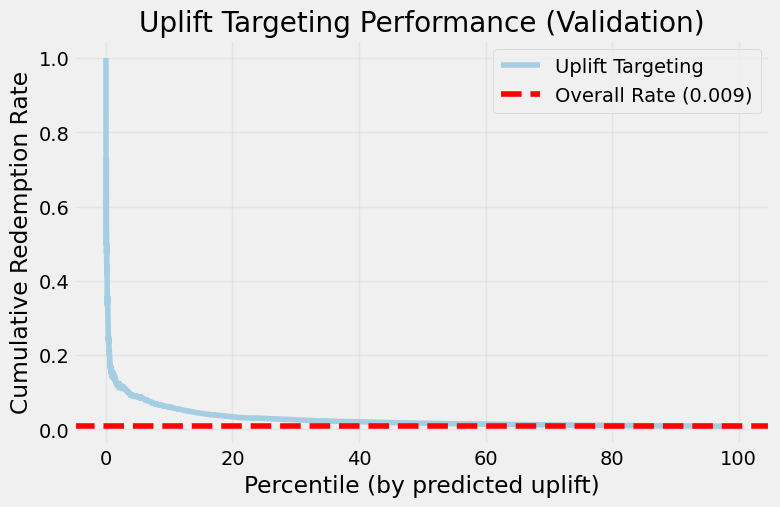

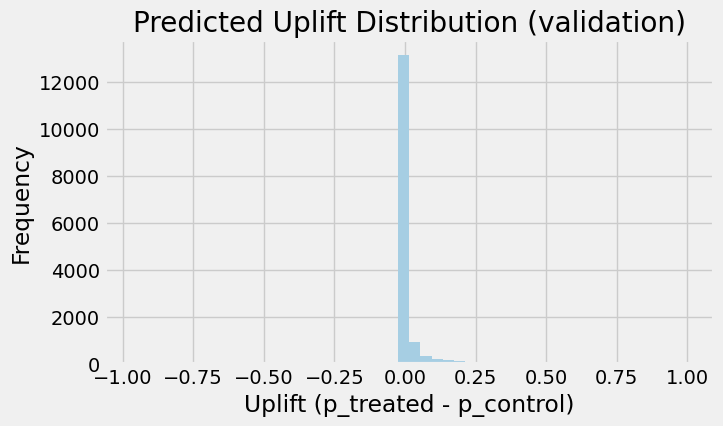

In [141]:
# Cell 13: Validation evaluation (real holdout) - two-model outputs
import numpy as np
import matplotlib.pyplot as plt

# --- Ensure variables exist ---
# p_treat_val, p_control_val, uplift_val_new, y_val, t_val must be present (from the two-model block)
assert 'p_treat_val' in globals() and 'p_control_val' in globals() and 'uplift_val_new' in globals(), \
    "Missing p_treat_val/p_control_val/uplift_val_new — run the two-model training block first."

# Flatten (they should already be 1d arrays)
p_treated_flat = np.array(p_treat_val).flatten()
p_control_flat = np.array(p_control_val).flatten()
uplift_flat = np.array(uplift_val_new).flatten()

# --- Build evaluation DataFrame ---
df_eval_val = pd.DataFrame({
    'predicted_uplift': uplift_flat,
    'p_treated': p_treated_flat,
    'p_control': p_control_flat,
    'redemption': y_val.values,
    'treatment': t_val.values
})

# Save evaluation raw file (optional)
df_eval_val.to_csv(os.path.join(OUTPUT_PATH, "validation_uplift_full_two_models_eval.csv"), index=False)

# --- Basic diagnostics ---
print("Validation Results (two-model):")
overall_val = df_eval_val['redemption'].mean()
treated_val = df_eval_val[df_eval_val['treatment']==1]['redemption'].mean()
control_val = df_eval_val[df_eval_val['treatment']==0]['redemption'].mean()
treatment_effect_val = treated_val - control_val

print(f"Overall redemption rate: {overall_val:.4f}")
print(f"Treated group redemption: {treated_val:.4f}")
print(f"Control group redemption: {control_val:.4f}")
print(f"Treatment effect (treated - control): {treatment_effect_val:.4f}")

# Uplift distribution summary and percentiles
print("\nUplift distribution summary:")
print(pd.Series(uplift_flat).describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]))

pct90 = np.percentile(uplift_flat, 90)
pct95 = np.percentile(uplift_flat, 95)
print(f"\n90th percentile uplift: {pct90:.6f}, 95th percentile uplift: {pct95:.6f}")
print("Proportion uplift > 0:", (uplift_flat > 0).mean())

# --- Top-k uplift targeting performance ---
for pct in [0.1, 0.2, 0.3]:
    top_n = int(pct * len(df_eval_val))
    top = df_eval_val.sort_values('predicted_uplift', ascending=False).head(top_n)
    top_red = top['redemption'].mean()
    lift = top_red - overall_val
    print(f"Top {int(pct*100)}% by uplift - Redemption: {top_red:.4f}, Lift: {lift:.4f}")

# --- Simple uplift targeting visualization (cumulative redemption by uplift percentile) ---
plt.figure(figsize=(8,5))
df_sorted = df_eval_val.sort_values('predicted_uplift', ascending=False).reset_index(drop=True)
df_sorted['percentile'] = (df_sorted.index / len(df_sorted)) * 100
df_sorted['cumulative_redemption'] = df_sorted['redemption'].expanding().mean()

plt.plot(df_sorted['percentile'], df_sorted['cumulative_redemption'], label='Uplift Targeting')
plt.axhline(y=overall_val, color='red', linestyle='--', label=f'Overall Rate ({overall_val:.3f})')
plt.xlabel('Percentile (by predicted uplift)')
plt.ylabel('Cumulative Redemption Rate')
plt.title('Uplift Targeting Performance (Validation)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Uplift distribution plot ---
plt.figure(figsize=(7,4))
plt.hist(uplift_flat, bins=50)
plt.title("Predicted Uplift Distribution (validation)")
plt.xlabel("Uplift (p_treated - p_control)")
plt.ylabel("Frequency")
plt.show()


In [142]:
# Cell 14: Top-K business output (top 10% example)
df_val_sorted = df_eval_val.sort_values('predicted_uplift', ascending=False).reset_index(drop=True)
k = int(0.10 * len(df_val_sorted))
top10 = df_val_sorted.head(k)
print("Top10% redemption:", top10['redemption'].mean())
print("Lift over overall:", top10['redemption'].mean() - overall_val)

# Save top customer list (customer ids from master: map back)
# We'll use validation indices from X_val -> find customer ids
# Map top uplift customers back to customer IDs safely
top10_with_ids = top10.copy()
top10_with_ids['customer_id'] = master.loc[X_val.index[top10_with_ids.index], 'customer_id'].values

# Save them
top10_with_ids.to_csv(os.path.join(OUTPUT_PATH, 'top10pct_uplift_customers.csv'), index=False)

print(f"✅ Saved top 10% uplift customers — total {len(top10_with_ids)} rows.")
display(top10_with_ids.head())



Top10% redemption: 0.059349074664964904
Lift over overall: 0.050417085383352045
✅ Saved top 10% uplift customers — total 1567 rows.


,predicted_uplift,p_treated,p_control,redemption,treatment,customer_id
0,0.996525,0.996525,2.229849e-07,1,1,1552
1,0.995088,0.995667,5.785872e-04,0,0,802
2,0.987758,0.987758,6.519905e-08,1,1,1042
3,0.986990,0.987034,4.374727e-05,0,1,501
4,0.981570,0.981571,7.366277e-07,1,1,484


In [143]:
# Cell 15: save model and uplift scores
joblib.dump(x_learner, os.path.join(OUTPUT_PATH, 'x_learner_lgbm.joblib'))
print("Saved model:", os.path.join(OUTPUT_PATH, 'x_learner_lgbm.joblib'))

# Save validation uplift predictions
df_eval_val_out = df_eval_val.copy()
df_eval_val_out.to_csv(os.path.join(OUTPUT_PATH, 'validation_uplift_predictions.csv'), index=False)
print("Saved validation uplift predictions to output/")


Saved model: output/x_learner_lgbm.joblib
Saved validation uplift predictions to output/


In [146]:
# --- Fix: retrain baseline on uplift features so baseline probs align with X_val_fixed ---
from lightgbm import LGBMClassifier
import joblib
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import numpy as np

print("Shapes (sanity):", "X_train_fixed", X_train_fixed.shape, "X_val_fixed", X_val_fixed.shape)
print("y_train len:", len(y_train), "y_val len:", len(y_val))

# 1) Retrain baseline model on the same features used by uplift (X_train_fixed)
baseline_retrain_params = {
    "n_estimators": 600,
    "learning_rate": 0.03,
    "num_leaves": 63,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1
}

# Handle class imbalance with scale_pos_weight
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos = float(neg / pos) if pos > 0 else 1.0
print("Train pos/neg:", pos, neg, "scale_pos_weight:", round(scale_pos,2))

baseline_on_uplift = LGBMClassifier(**baseline_retrain_params, scale_pos_weight=scale_pos)
baseline_on_uplift.fit(X_train_fixed, y_train)

# 2) Predict aligned baseline probabilities on X_val_fixed
baseline_probs_aligned = baseline_on_uplift.predict_proba(X_val_fixed)[:,1]
baseline_pred_label = (baseline_probs_aligned > 0.5).astype(int)

# 3) Save the retrained baseline so your app can use it
joblib.dump(baseline_on_uplift, os.path.join(OUTPUT_PATH, "baseline_lgbm_on_uplift_features.joblib"))
print("Saved retrained baseline to:", os.path.join(OUTPUT_PATH, "baseline_lgbm_on_uplift_features.joblib"))

# 4) Basic baseline metrics on this aligned holdout
try:
    base_auc_new = roc_auc_score(y_val, baseline_probs_aligned)
except Exception as e:
    base_auc_new = np.nan
base_acc_new = accuracy_score(y_val, baseline_pred_label)
base_f1_new = f1_score(y_val, baseline_pred_label)

print("\nBaseline (retrained on uplift features) metrics:")
print("AUC:", base_auc_new)
print("Accuracy:", base_acc_new)
print("F1:", base_f1_new)

# 5) Now recalc uplift evaluation using the already computed df_eval_val (or rebuild if needed)
# If df_eval_val length mismatched earlier, rebuild it from two-model outputs.
if 'df_eval_val' not in globals() or len(df_eval_val) != len(baseline_probs_aligned):
    print("Rebuilding df_eval_val to align with X_val_fixed (using two-model outputs).")
    df_eval_val = pd.DataFrame({
        'predicted_uplift': np.array(uplift_val_new).flatten(),
        'p_treated': np.array(p_treat_val).flatten(),
        'p_control': np.array(p_control_val).flatten(),
        'redemption': y_val.values,
        'treatment': t_val.values
    })

# 6) Compute uplift summary metrics (same as before)
overall_val = df_eval_val['redemption'].mean()
treated_val = df_eval_val[df_eval_val['treatment']==1]['redemption'].mean()
control_val = df_eval_val[df_eval_val['treatment']==0]['redemption'].mean()
uplift_effect = treated_val - control_val
top10 = df_eval_val.sort_values('predicted_uplift', ascending=False).head(int(0.10 * len(df_eval_val)))
uplift_top10 = top10['redemption'].mean() - overall_val

print("\nUplift model summary (aligned):")
print("Overall redemption rate:", overall_val)
print("Treated redemption:", treated_val)
print("Control redemption:", control_val)
print("Treatment effect (treated - control):", uplift_effect)
print("Top10 lift (uplift targeting):", round(uplift_top10, 6))

# 7) Final comparison summary printed (simpler)
print("\nFinal comparison (baseline vs uplift):")
print("Baseline AUC (aligned):", base_auc_new)
print("Baseline Accuracy:", round(base_acc_new,4), "Baseline F1:", round(base_f1_new,4))
print("Uplift average treatment effect:", round(uplift_effect,6))
print("Top10 uplift lift:", round(uplift_top10,6))

# 8) Store baseline_probs_aligned and make it available for next cells
yb_pred_prob_aligned = baseline_probs_aligned  # name used by later cells if needed


Shapes (sanity): X_train_fixed (62695, 21) X_val_fixed (15674, 21)
y_train len: 62695 y_val len: 15674
Train pos/neg: 589 62106 scale_pos_weight: 105.44
Saved retrained baseline to: output/baseline_lgbm_on_uplift_features.joblib

Baseline (retrained on uplift features) metrics:
AUC: 0.904851110007541
Accuracy: 0.9751818297818042
F1: 0.23274161735700197

Uplift model summary (aligned):
Overall redemption rate: 0.008931989281612863
Treated redemption: 0.010314639854381556
Control redemption: 0.005076142131979695
Treatment effect (treated - control): 0.0052384977224018605
Top10 lift (uplift targeting): 0.050417

Final comparison (baseline vs uplift):
Baseline AUC (aligned): 0.904851110007541
Baseline Accuracy: 0.9752 Baseline F1: 0.2327
Uplift average treatment effect: 0.005238
Top10 uplift lift: 0.050417


In [147]:
import json, os

# BEFORE encoding (i.e., use X_train / X_val, not X_train_fixed)
raw_features = list(X_train.columns)                # columns before label-encoding
date_cols = [c for c in X_train.columns if str(X_train[c].dtype).startswith('datetime64')]

# build label maps for object columns so API can encode identically
label_maps = {}
for c in X_train.columns:
    if X_train[c].dtype == 'object':
        cats = X_train[c].astype(str).fillna('missing').unique().tolist()
        cats = sorted(cats)
        # ensure 'missing' exists as a safe default
        if 'missing' not in cats: cats = ['missing'] + cats
        label_maps[c] = {v:i for i,v in enumerate(cats)}

meta = {
    "features": raw_features,
    "date_cols": date_cols,
    "uplift_threshold": 0.002,   # lower for demo
    "supports_components": True
}
json.dump(meta, open("output/uplift_meta.json","w"))


os.makedirs("output", exist_ok=True)
json.dump(meta, open("output/uplift_meta.json","w"))
json.dump(label_maps, open("output/label_maps.json","w"))
print("Saved output/uplift_meta.json and output/label_maps.json")


Saved output/uplift_meta.json and output/label_maps.json


In [148]:
# Demographics (key: customer_id)
cust_demo_feat = cust_demo.copy()
if 'customer_id' not in cust_demo_feat.columns:
    cust_demo_feat = cust_demo_feat.reset_index().rename(columns={'index':'customer_id'})
cust_demo_feat.to_csv("src/cust_demo_feat.csv", index=False)

# Transactions aggregates (merge your cust_features + recency_df + freq_df)
cust_trans_features = cust_features.merge(recency_df, on='customer_id', how='outer') \
                                   .merge(freq_df,    on='customer_id', how='outer') \
                                   .fillna(0)
cust_trans_features.to_csv("src/cust_trans_features.csv", index=False)

# Campaign features (campaign_type, campaign_duration, etc.)
camp_feat = campaign.copy()
if 'campaign_duration' not in camp_feat.columns:
    # if needed
    for col in ['start_date','end_date']:
        if col in camp_feat.columns:
            camp_feat[col] = pd.to_datetime(camp_feat[col], errors='coerce')
    if 'start_date' in camp_feat.columns and 'end_date' in camp_feat.columns:
        camp_feat['campaign_duration'] = (camp_feat['end_date'] - camp_feat['start_date']).dt.days.fillna(0).astype(int)
    else:
        camp_feat['campaign_duration'] = 0
camp_feat.to_csv("src/campaign_feat.csv", index=False)

print("Saved: src/cust_demo_feat.csv, src/cust_trans_features.csv, src/campaign_feat.csv")


Saved: src/cust_demo_feat.csv, src/cust_trans_features.csv, src/campaign_feat.csv


In [ ]:
# Robust: build val_preds aligned to X_val (use two-model outputs)
import numpy as np
import pandas as pd

# 1) pick the uplift/prob arrays that are actually aligned to X_val
# prefer the two-model outputs (p_treat_val / p_control_val / uplift_val_new)
if 'uplift_val_new' in globals() and 'p_treat_val' in globals() and 'p_control_val' in globals():
    uplift_arr = np.array(uplift_val_new).flatten()
    p_treat_arr = np.array(p_treat_val).flatten()
    p_control_arr = np.array(p_control_val).flatten()
    source = "two-model (p_treat_val/p_control_val/uplift_val_new)"
elif 'uplift_val' in globals():
    # fallback to existing uplift_val (may be x_learner output) but ensure lengths
    uplift_arr = np.array(uplift_val).flatten()
    p_treat_arr = np.array(p_treat).flatten() if 'p_treat' in globals() else None
    p_control_arr = np.array(p_control).flatten() if 'p_control' in globals() else None
    source = "legacy uplift_val / x_learner"
else:
    raise RuntimeError("No uplift arrays found. Run the two-model block or the uplift learner predict first.")

# 2) sanity lengths and align with X_val.index
n_Xval = len(X_val.index)
n_uplift = len(uplift_arr)
print(f"Length X_val: {n_Xval}, length uplift array: {n_uplift}  (source: {source})")

if n_uplift != n_Xval:
    # If mismatch, prefer to truncate to the minimum length and warn (or raise)
    m = min(n_Xval, n_uplift)
    print(f"⚠️ Length mismatch detected. Truncating to {m} rows to ensure alignment.")
    uplift_arr = uplift_arr[:m]
    p_treat_arr = p_treat_arr[:m] if p_treat_arr is not None else None
    p_control_arr = p_control_arr[:m] if p_control_arr is not None else None
    
    # Adjust index mapping (use first m rows of X_val.index / master.loc)
    idx = X_val.index[:m]
else:
    idx = X_val.index

# 3) build DataFrame using aligned index (use master.loc with that index)
val_preds = pd.DataFrame({
    "customer_id": master.loc[idx, "customer_id"].values,
    "campaign_id": master.loc[idx, "campaign_id"].values,
    "coupon_id": master.loc[idx, "coupon_id"].values,
    "p_with_coupon": p_treat_arr if p_treat_arr is not None else np.nan,
    "p_without_coupon": p_control_arr if p_control_arr is not None else np.nan,
    "uplift": uplift_arr,
    "actual_redemption": master.loc[idx, "y"].values,   # master already has y
    "treatment": master.loc[idx, "treatment"].values
})

print("val_preds shape:", val_preds.shape)
print("uplift summary (describe):")
display(pd.Series(val_preds['uplift']).describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]))

# 4) get top positive uplift samples (top N)
topN = 100
positive_samples = val_preds.sort_values("uplift", ascending=False).head(topN)
display(positive_samples.head(10))

# 5) save outputs
val_preds.to_csv(os.path.join(OUTPUT_PATH, "validation_uplift_aligned.csv"), index=False)
positive_samples.to_csv(os.path.join(OUTPUT_PATH, "top_positive_uplift_aligned.csv"), index=False)
print(f"Saved: output/validation_uplift_aligned.csv and output/top_positive_uplift_aligned.csv (top {topN})")


Length X_val: 15674, length uplift array: 15674  (source: two-model (p_treat_val/p_control_val/uplift_val_new))
val_preds shape: (15674, 8)
uplift summary (describe):


count    1.567400e+04
mean     3.467461e-02
std      1.311329e-01
min     -9.649825e-01
1%      -2.758257e-04
5%       2.219445e-07
10%      1.091245e-06
25%      8.629411e-06
50%      1.149434e-04
75%      3.348794e-03
90%      5.537172e-02
95%      2.235761e-01
99%      7.714600e-01
max      9.965250e-01
Name: uplift, dtype: float64

,customer_id,campaign_id,coupon_id,p_with_coupon,p_without_coupon,uplift,actual_redemption,treatment
6568,1574,13,468,0.996525,2.229849e-07,0.996525,1,1
14316,235,9,468,0.995667,5.785872e-04,0.995088,0,0
15034,1052,13,21,0.987758,6.519905e-08,0.987758,1,1
15412,626,13,786,0.987034,4.374727e-05,0.986990,0,1
12369,162,13,21,0.981571,7.366277e-07,0.981570,1,1
9280,1136,8,9,0.981186,3.755836e-07,0.981186,1,1
898,1558,8,705,0.977938,6.622977e-07,0.977937,0,1
14995,1549,8,6,0.991213,1.586632e-02,0.975346,1,1
577,891,8,754,0.973234,2.282056e-04,0.973006,1,1
7526,959,13,468,0.968267,2.467837e-06,0.968264,1,1


Saved: output/validation_uplift_aligned.csv and output/top_positive_uplift_aligned.csv (top 100)


In [156]:
# Robust: build aligned val_preds and save top-50 positive uplift IDs
import numpy as np
import pandas as pd
import os

# choose the uplift/prob arrays that were predicted on X_val_fixed
# prefer two-model outputs if available
if 'uplift_val_new' in globals() and 'p_treat_val' in globals() and 'p_control_val' in globals():
    uplift_arr = np.array(uplift_val_new).flatten()
    p_treat_arr = np.array(p_treat_val).flatten()
    p_control_arr = np.array(p_control_val).flatten()
    source = "two-model (p_treat_val/p_control_val/uplift_val_new)"
elif 'uplift_val' in globals():
    uplift_arr = np.array(uplift_val).flatten()
    p_treat_arr = np.array(p_treat).flatten() if 'p_treat' in globals() else None
    p_control_arr = np.array(p_control).flatten() if 'p_control' in globals() else None
    source = "x_learner uplift_val"
else:
    raise RuntimeError("No uplift arrays found. Run the uplift prediction block first (two-model or x_learner).")

# lengths
n_Xval = len(X_val.index)
n_uplift = len(uplift_arr)
print(f"Source: {source}")
print("Length X_val.index:", n_Xval, "Length uplift array:", n_uplift)

# align/truncate if mismatch (prefer not to pad)
if n_uplift != n_Xval:
    m = min(n_Xval, n_uplift)
    print(f"⚠️ Length mismatch detected. Truncating both to {m} rows to ensure alignment.")
    uplift_arr = uplift_arr[:m]
    p_treat_arr = p_treat_arr[:m] if p_treat_arr is not None else None
    p_control_arr = p_control_arr[:m] if p_control_arr is not None else None
    idx = X_val.index[:m]
else:
    idx = X_val.index

# Build aligned DataFrame using master rows for those idx
val_preds = pd.DataFrame({
    "customer_id": master.loc[idx, "customer_id"].values,
    "campaign_id": master.loc[idx, "campaign_id"].values,
    "coupon_id": master.loc[idx, "coupon_id"].values,
    "p_with_coupon": p_treat_arr if p_treat_arr is not None else np.nan,
    "p_without_coupon": p_control_arr if p_control_arr is not None else np.nan,
    "uplift": uplift_arr,
    "actual_redemption": master.loc[idx, "y"].values,   # master has y
    "treatment": master.loc[idx, "treatment"].values
})

print("val_preds shape:", val_preds.shape)
print("uplift describe:")
display(pd.Series(val_preds['uplift']).describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]))

# Filter only positive uplift (you asked > 0.00). For demo you may want > 0.002 or top-percentile.
threshold = 0.0   # change to 0.002 for slightly stricter selection, or use percentile logic below
positive_uplift = val_preds[val_preds["uplift"] > threshold].sort_values("uplift", ascending=False)

# If you prefer percentile-based top-k (e.g., top 10%), uncomment:
# pct = 0.10
# k = int(pct * len(val_preds))
# positive_uplift = val_preds.sort_values("uplift", ascending=False).head(k)

# Save top 50
top50 = positive_uplift.head(50)
out_path = "top_positive_uplift.csv"
top50.to_csv(out_path, index=False)
top50.to_csv(os.path.join(OUTPUT_PATH, "top_positive_uplift_aligned.csv"), index=False)

print(f"✅ Saved top {len(top50)} positive uplift IDs to {out_path} and output/top_positive_uplift_aligned.csv")
display(top50.head(10))


Source: two-model (p_treat_val/p_control_val/uplift_val_new)
Length X_val.index: 15674 Length uplift array: 15674
val_preds shape: (15674, 8)
uplift describe:


count    1.567400e+04
mean     3.467461e-02
std      1.311329e-01
min     -9.649825e-01
1%      -2.758257e-04
5%       2.219445e-07
10%      1.091245e-06
25%      8.629411e-06
50%      1.149434e-04
75%      3.348794e-03
90%      5.537172e-02
95%      2.235761e-01
99%      7.714600e-01
max      9.965250e-01
Name: uplift, dtype: float64

✅ Saved top 50 positive uplift IDs to top_positive_uplift.csv and output/top_positive_uplift_aligned.csv


,customer_id,campaign_id,coupon_id,p_with_coupon,p_without_coupon,uplift,actual_redemption,treatment
6568,1574,13,468,0.996525,2.229849e-07,0.996525,1,1
14316,235,9,468,0.995667,5.785872e-04,0.995088,0,0
15034,1052,13,21,0.987758,6.519905e-08,0.987758,1,1
15412,626,13,786,0.987034,4.374727e-05,0.986990,0,1
12369,162,13,21,0.981571,7.366277e-07,0.981570,1,1
9280,1136,8,9,0.981186,3.755836e-07,0.981186,1,1
898,1558,8,705,0.977938,6.622977e-07,0.977937,0,1
14995,1549,8,6,0.991213,1.586632e-02,0.975346,1,1
577,891,8,754,0.973234,2.282056e-04,0.973006,1,1
7526,959,13,468,0.968267,2.467837e-06,0.968264,1,1


In [157]:
uplift_threshold = np.percentile(df_eval_val["predicted_uplift"], 90)
print("90th percentile uplift:", uplift_threshold)


90th percentile uplift: 0.05537171805189702


In [158]:
# Sanity checks
import numpy as np, pandas as pd

print("master shape:", master.shape)
print("\nRedemption counts by overall:")
print(master['y'].value_counts())

print("\nTreatment counts:")
print(master['treatment'].value_counts())

print("\nRedemption rate by treatment (original master):")
print(master.groupby('treatment')['y'].agg(['count','sum','mean']))

# In validation results: distribution summary of predicted uplift
print("\nUplift distribution (validation):")
print(pd.Series(uplift_val.flatten()).describe(percentiles=[.25,.5,.75,.9,.95]))

# Inspect p_treated and p_control distributions
try:
    print("\nP_treated stats:", pd.Series(p_treat_flat).describe())
    print("P_control stats:", pd.Series(p_control_flat).describe())
except Exception as e:
    print("Could not describe p_treat/p_control:", e)

# Quick check: how many validation rows have uplift > 0
print("\nCount uplift > 0 on val:", (uplift_val.flatten() > 0).sum(), "/", len(uplift_val.flatten()))
print("Proportion uplift > 0:", ((uplift_val.flatten() > 0).mean()))


master shape: (78369, 28)

Redemption counts by overall:
y
0    77640
1      729
Name: count, dtype: int64

Treatment counts:
treatment
1    57684
0    20685
Name: count, dtype: int64

Redemption rate by treatment (original master):
           count  sum      mean
treatment                      
0          20685   93  0.004496
1          57684  636  0.011026

Uplift distribution (validation):
count    15842.000000
mean        -0.525286
std          0.199311
min         -1.000000
25%         -0.621599
50%         -0.556706
75%         -0.474652
90%         -0.474652
95%          0.000000
max          0.525348
dtype: float64

P_treated stats: count    15842.00000
mean         0.03516
std          0.18926
min         -1.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
dtype: float64
P_control stats: count    1.567400e+04
mean     1.804499e-03
std      2.964048e-02
min      5.216460e-11
25%      1.323421e-08
50%      1.155774e-07
75%      1.475682e-

In [159]:
k = int(0.10 * len(val_preds))                # top 10%
demo_ids = val_preds.sort_values('uplift', ascending=False).head(k)
demo_ids.to_csv("output/demo_top10pct_ids.csv", index=False)


In [161]:
# --- Get feature names used during baseline training ---
baseline_feature_names = clf_base.booster_.feature_name()

# --- Fix column alignment for validation data ---
X_val_baseline_aligned = X_val_fixed.reindex(columns=baseline_feature_names, fill_value=0)

# --- Now safely predict ---
baseline_probs = clf_base.predict_proba(X_val_baseline_aligned)[:, 1]

# --- Combine with IDs from master (align indices) ---
df_baseline_val = pd.DataFrame({
    "customer_id": master.loc[X_val.index, "customer_id"].values,
    "campaign_id": master.loc[X_val.index, "campaign_id"].values,
    "coupon_id": master.loc[X_val.index, "coupon_id"].values,
    "baseline_prob": baseline_probs
})

# --- Sort & save ---
df_baseline_val_sorted = df_baseline_val.sort_values("baseline_prob", ascending=False).reset_index(drop=True)
top50_baseline = df_baseline_val_sorted.head(50)
top50_baseline.to_csv(os.path.join(OUTPUT_PATH, "top50_baseline_customers.csv"), index=False)

print("✅ Saved top 50 baseline customers to output/top50_baseline_customers.csv")
display(top50_baseline.head(10))


✅ Saved top 50 baseline customers to output/top50_baseline_customers.csv


,customer_id,campaign_id,coupon_id,baseline_prob
0,1257,8,8,0.973864
1,1052,8,9,0.960263
2,467,13,960,0.947424
3,1549,8,6,0.946643
4,626,5,689,0.946349
5,1574,13,468,0.942176
6,153,2,347,0.941961
7,1574,13,960,0.941201
8,113,29,643,0.940632
9,1026,30,310,0.927302


In [162]:
# 1) feature alignment used for baseline predictions
print("Baseline model features (len):", len(clf_base.booster_.feature_name()))
print("X_val_fixed cols (len):", X_val_fixed.shape[1])

# align X_val to baseline features (safe)
baseline_cols = clf_base.booster_.feature_name()
X_val_baseline_aligned = X_val_fixed.reindex(columns=baseline_cols, fill_value=0)

# 2) baseline probabilities summary
baseline_probs = clf_base.predict_proba(X_val_baseline_aligned)[:,1]
import numpy as np
print("Baseline prob stats:", np.min(baseline_probs), np.median(baseline_probs), np.mean(baseline_probs), np.max(baseline_probs))

# 3) uplift stats (you already have df_eval_val)
print("Uplift stats:", df_eval_val['predicted_uplift'].describe())
print("Count with uplift > 0:", (df_eval_val['predicted_uplift']>0).sum(), "/", len(df_eval_val))

# 4) show a small sample compared
cmp = pd.DataFrame({
    "customer_id": master.loc[X_val.index,"customer_id"].values,
    "baseline_prob": baseline_probs,
    "p_with": df_eval_val['p_treated'].values,
    "p_without": df_eval_val['p_control'].values,
    "uplift": df_eval_val['predicted_uplift'].values
})
display(cmp.sort_values("uplift", ascending=False).head(10))


Baseline model features (len): 22
X_val_fixed cols (len): 21
Baseline prob stats: 1.830289188298747e-08 7.992427567009264e-05 0.00899570428478632 0.9738638120329938
Uplift stats: count    15674.000000
mean         0.034675
std          0.131133
min         -0.964982
25%          0.000009
50%          0.000115
75%          0.003349
max          0.996525
Name: predicted_uplift, dtype: float64
Count with uplift > 0: 15235 / 15674


,customer_id,baseline_prob,p_with,p_without,uplift
6568,1574,0.942176,0.996525,2.229849e-07,0.996525
14316,235,0.010930,0.995667,5.785872e-04,0.995088
15034,1052,0.721535,0.987758,6.519905e-08,0.987758
15412,626,0.203529,0.987034,4.374727e-05,0.986990
12369,162,0.910254,0.981571,7.366277e-07,0.981570
9280,1136,0.909382,0.981186,3.755836e-07,0.981186
898,1558,0.127100,0.977938,6.622977e-07,0.977937
14995,1549,0.946643,0.991213,1.586632e-02,0.975346
577,891,0.726086,0.973234,2.282056e-04,0.973006
7526,959,0.801392,0.968267,2.467837e-06,0.968264


In [163]:
# run in notebook where df_eval_val exists
print(df_eval_val[['p_treated','p_control','predicted_uplift']].describe(percentiles=[.25,.5,.75,.9,.95]))
print("Count uplift>0:", (df_eval_val['predicted_uplift']>0).sum()," / ", len(df_eval_val))


          p_treated     p_control  predicted_uplift
count  1.567400e+04  1.567400e+04      15674.000000
mean   3.647911e-02  1.804499e-03          0.034675
std    1.305044e-01  2.964048e-02          0.131133
min    4.459667e-09  5.216460e-11         -0.964982
25%    1.053244e-05  1.323421e-08          0.000009
50%    1.321123e-04  1.155774e-07          0.000115
75%    3.616985e-03  1.475682e-06          0.003349
90%    5.814971e-02  2.291140e-05          0.055372
95%    2.284468e-01  1.995482e-04          0.223576
max    9.965252e-01  9.964739e-01          0.996525
Count uplift>0: 15235  /  15674


In [164]:
# sorts by uplift descending
top = df_eval_val.assign(customer_id=master.loc[X_val.index,'customer_id'].values).sort_values('predicted_uplift', ascending=False).head(10)
display(top)


,predicted_uplift,p_treated,p_control,redemption,treatment,customer_id
6568,0.996525,0.996525,2.229849e-07,1,1,1574
14316,0.995088,0.995667,5.785872e-04,0,0,235
15034,0.987758,0.987758,6.519905e-08,1,1,1052
15412,0.986990,0.987034,4.374727e-05,0,1,626
12369,0.981570,0.981571,7.366277e-07,1,1,162
9280,0.981186,0.981186,3.755836e-07,1,1,1136
898,0.977937,0.977938,6.622977e-07,0,1,1558
14995,0.975346,0.991213,1.586632e-02,1,1,1549
577,0.973006,0.973234,2.282056e-04,1,1,891
7526,0.968264,0.968267,2.467837e-06,1,1,959


In [165]:
print("Baseline model features (len):", getattr(clf_base, "n_features_in_", None))
print("X_val_fixed shape:", X_val_fixed.shape)


Baseline model features (len): 22
X_val_fixed shape: (15674, 21)


In [167]:
# 1. What the model thinks it was trained on
try:
    # LightGBM sklearn wrapper
    baseline_features = clf_base.booster_.feature_name()
except Exception:
    # fallback for other object shapes
    baseline_features = getattr(clf_base, "feature_name_in_", None)

print("Baseline model features (len):", len(baseline_features))
print(baseline_features)

# 2. What X_val_fixed has
print("X_val_fixed cols (len):", X_val_fixed.shape[1])
print(list(X_val_fixed.columns))

# 3. Show difference
set_model = set(baseline_features)
set_val   = set(X_val_fixed.columns)
print("Features missing in X_val_fixed:", sorted(list(set_model - set_val)))
print("Extra features in X_val_fixed:", sorted(list(set_val - set_model)))


Baseline model features (len): 22
['id', 'campaign_type', 'campaign_duration', 'coupon_n_items', 'coupon_n_brands', 'coupon_n_categories', 'coupon_dominant_brand_type', 'age_range', 'marital_status', 'rented', 'family_size', 'no_of_children', 'income_bracket', 'qty_sum', 'qty_mean', 'spend_sum', 'spend_mean', 'avg_other_discount', 'avg_coupon_discount', 'days_since_last_purchase', 'num_transactions', 'synthetic']
X_val_fixed cols (len): 21
['id', 'campaign_type', 'campaign_duration', 'coupon_n_items', 'coupon_n_brands', 'coupon_n_categories', 'coupon_dominant_brand_type', 'age_range', 'marital_status', 'rented', 'family_size', 'no_of_children', 'income_bracket', 'qty_sum', 'qty_mean', 'spend_sum', 'spend_mean', 'avg_other_discount', 'avg_coupon_discount', 'days_since_last_purchase', 'num_transactions']
Features missing in X_val_fixed: ['synthetic']
Extra features in X_val_fixed: []


In [168]:
# create aligned validation matrix for baseline predictions
baseline_features = list(baseline_features)   # ensure list
X_val_for_baseline = X_val_fixed.reindex(columns=baseline_features, fill_value=0)

# optional: if model expects numpy array and you want to silence shape-check
# X_val_for_baseline = X_val_for_baseline.values

# now predict
baseline_probs = clf_base.predict_proba(X_val_for_baseline)[:, 1]
print("Baseline prob stats:", baseline_probs.min(), baseline_probs.mean(), baseline_probs.max())


Baseline prob stats: 1.830289188298747e-08 0.00899570428478632 0.9738638120329938


In [169]:
# apply saved label maps (label_maps = json.load(...))
def apply_label_maps_df(df, label_maps):
    df2 = df.copy()
    for c, mapping in label_maps.items():
        if c in df2.columns:
            df2[c] = df2[c].astype(str).map(mapping).fillna(mapping.get("missing", 0)).astype(int)
    return df2

X_val_for_baseline = convert_dates_to_numeric(X_val)          # same helper as training
X_val_for_baseline = apply_label_maps_df(X_val_for_baseline, label_maps)
X_val_for_baseline = X_val_for_baseline.reindex(columns=baseline_features, fill_value=0)
baseline_probs = clf_base.predict_proba(X_val_for_baseline)[:,1]


In [170]:
df_base_val = pd.DataFrame({
    "customer_id": master.loc[X_val.index, "customer_id"].values,
    "campaign_id": master.loc[X_val.index, "campaign_id"].values,
    "coupon_id": master.loc[X_val.index, "coupon_id"].values,
    "baseline_prob": baseline_probs
})

top50_baseline = df_base_val.sort_values("baseline_prob", ascending=False).head(50)
top50_baseline.to_csv("output/top50_baseline.csv", index=False)
display(top50_baseline.head(10))
print("Saved output/top50_baseline.csv")


,customer_id,campaign_id,coupon_id,baseline_prob
564,153,2,347,0.897729
104,823,2,347,0.762314
10273,632,26,358,0.754129
11527,626,5,689,0.646622
9191,510,26,1020,0.434087
6801,1026,30,310,0.399723
5807,510,26,475,0.392054
6843,823,13,844,0.333268
6994,632,26,529,0.304614
272,1472,7,986,0.282892


Saved output/top50_baseline.csv


In [171]:
# Recreate the train_test_split once and use X_val_fixed for both baseline & uplift predictions
X = master[feature_cols]                 # same features used for uplift
y = master['y'].astype(int)
t = master['treatment'].astype(int)

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val, t_train, t_val = train_test_split(
    X, y, t, test_size=0.2, random_state=42, stratify=t)

# then build X_val_fixed and X_val_for_baseline from X_val (same index)


In [172]:
# 1. get trained feature list
try:
    baseline_features = list(clf_base.booster_.feature_name())
except Exception:
    baseline_features = list(getattr(clf_base, "feature_name_in_", X_train_fixed.columns.tolist()))

# 2. Build X_val_for_baseline (best-effort)
X_val_tmp = convert_dates_to_numeric(X_val)   # same helper
X_val_tmp = encode_categoricals(X_val_tmp)    # ensure categorical -> numeric (may differ from training)
X_val_for_baseline = X_val_tmp.reindex(columns=baseline_features, fill_value=0)

# 3. predict
baseline_probs = clf_base.predict_proba(X_val_for_baseline)[:,1]

# 4. save top50
df_base_val = pd.DataFrame({
    "customer_id": master.loc[X_val.index, "customer_id"].values,
    "campaign_id": master.loc[X_val.index, "campaign_id"].values,
    "coupon_id": master.loc[X_val.index, "coupon_id"].values,
    "baseline_prob": baseline_probs
})
top50_baseline = df_base_val.sort_values("baseline_prob", ascending=False).head(50)
top50_baseline.to_csv("output/top50_baseline.csv", index=False)
print("Saved top50_baseline.csv")
display(top50_baseline.head(10))


Saved top50_baseline.csv


,customer_id,campaign_id,coupon_id,baseline_prob
2377,1257,8,8,0.973864
3826,1052,8,9,0.960263
12508,467,13,960,0.947424
14995,1549,8,6,0.946643
11527,626,5,689,0.946349
6568,1574,13,468,0.942176
564,153,2,347,0.941961
12119,1574,13,960,0.941201
3476,113,29,643,0.940632
6801,1026,30,310,0.927302
